In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

RANDOM_STATE=42
np.random.seed(RANDOM_STATE)
# 폰트 준비
import platform
# 운영체제를 확인하여 폰트 자동 지정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')
print("설정완료")

설정완료


In [15]:
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

print("train:", train_df.shape, "| test:", test_df.shape)
train_df.head()

train: (891, 12) | test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
experiment_log = []  # 실험 결과가 쌓이는 곳


def run_experiment(name, pipeline, X_tr, y_tr, X_va, y_va, cv=5):
    """모델을 학습시키고, 성능과 하이퍼파라미터를 experiment_log에 자동으로 기록합니다.

    반환값은 지금까지의 전체 실험 기록을 검증 정확도 순으로 정렬한 DataFrame입니다.
    """
    pipeline.fit(X_tr, y_tr)

    cv_scores = cross_val_score(pipeline, X_tr, y_tr, cv=cv, scoring="accuracy")
    row = {
        "실험명": name,
        "train 정확도": pipeline.score(X_tr, y_tr),
        "검증 정확도": pipeline.score(X_va, y_va),
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std(),
    }
    row.update(pipeline.named_steps["model"].get_params())
    experiment_log.append(row)

    log_df = pd.DataFrame(experiment_log)
    return log_df.sort_values("검증 정확도", ascending=False).reset_index(drop=True)


def show_log(columns=None):
    """실험 기록을 보여줍니다. columns를 지정하면 그 컬럼들만 골라서 봅니다.

    예: show_log(["실험명", "검증 정확도", "n_estimators", "max_depth"])
    """
    log_df = pd.DataFrame(experiment_log).sort_values("검증 정확도", ascending=False).reset_index(drop=True)
    return log_df[columns] if columns else log_df

In [17]:
print("결측치 개수")
print(train_df.isnull().sum())
print()
print("전체 생존율:", train_df["Survived"].mean().round(3))

결측치 개수
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

전체 생존율: 0.384


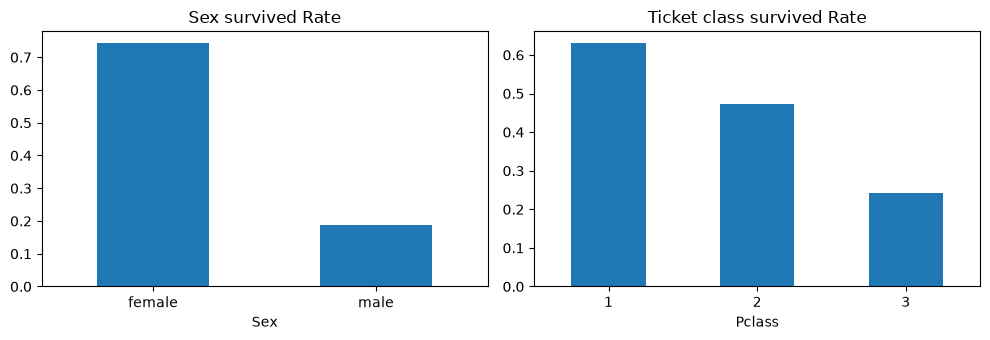

In [18]:
# 성별과 티켓 등급에 따라 생존율이 크게 갈립니다.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
train_df.groupby("Sex")["Survived"].mean().plot.bar(ax=axes[0], title="Sex survived Rate", rot=0)
train_df.groupby("Pclass")["Survived"].mean().plot.bar(ax=axes[1], title="Ticket class survived Rate", rot=0)
plt.tight_layout()
plt.show()

In [19]:
def add_features(df):
    """Name, SibSp/Parch, Cabin으로부터 파생 변수를 만듭니다."""
    df = df.copy()

    # Name에서 호칭 추출: "Braund, Mr. Owen Harris" -> "Mr"
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    common = ["Mr", "Mrs", "Miss", "Master"]
    df["Title"] = df["Title"].where(df["Title"].isin(common), "Rare")

    # 가족 규모와 혼자 탑승 여부
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1)

    # Cabin은 77%가 결측이라 값을 채우는 대신, 정보가 있는지 여부를 변수로 씁니다.
    df["HasCabin"] = df["Cabin"].notnull()

    return df


train_fe = add_features(train_df)
test_fe = add_features(test_df)

train_fe.groupby("Title")["Survived"].agg(["mean", "count"])

,mean,count
Title,,
Master,0.575000,40
Miss,0.702703,185
Mr,0.156673,517
Mrs,0.793651,126
Rare,0.347826,23


In [20]:
numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title", "IsAlone", "HasCabin"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

X = train_fe[numeric_features + categorical_features]
y = train_fe["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("train:", X_train.shape, "| val:", X_val.shape)

train: (712, 11) | val: (179, 11)


In [21]:
def plot_confusion(pipeline, X, y, title):
    ConfusionMatrixDisplay.from_estimator(
        pipeline, X, y,
        display_labels=["사망(0)", "생존(1)"],
        cmap="Blues",
    )
    plt.title(title)
    plt.show()
    print(classification_report(y, pipeline.predict(X), target_names=["사망(0)", "생존(1)"]))


def plot_feature_importance(pipeline, title, top_n=15):
    model = pipeline.named_steps["model"]
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        print(f"{title}: 이 모델은 feature_importances_나 coef_가 없어서 중요도를 그릴 수 없습니다.")
        return

    order = np.argsort(importances)[-top_n:]
    plt.figure(figsize=(7, 5))
    plt.barh(range(len(order)), importances[order])
    plt.yticks(range(len(order)), feature_names[order])
    plt.xlabel("중요도")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [22]:
## 7. 실험 1: 로지스틱 회귀 (베이스라인)
log_reg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

run_experiment("로지스틱 회귀", log_reg_pipe, X_train, y_train, X_val, y_val)[
    ["실험명", "train 정확도", "검증 정확도", "CV 평균"]
]


,실험명,train 정확도,검증 정확도,CV 평균
0,로지스틱 회귀,0.832865,0.832402,0.824495


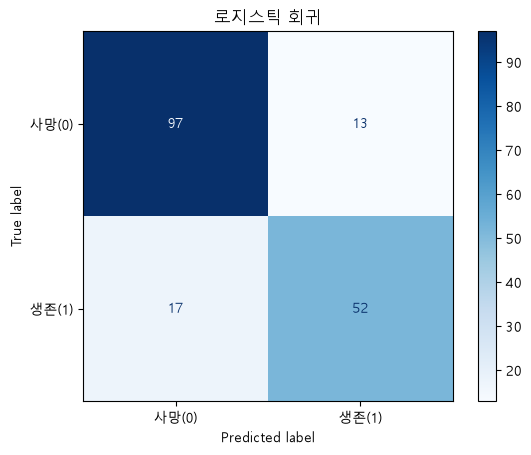

              precision    recall  f1-score   support

       사망(0)       0.85      0.88      0.87       110
       생존(1)       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



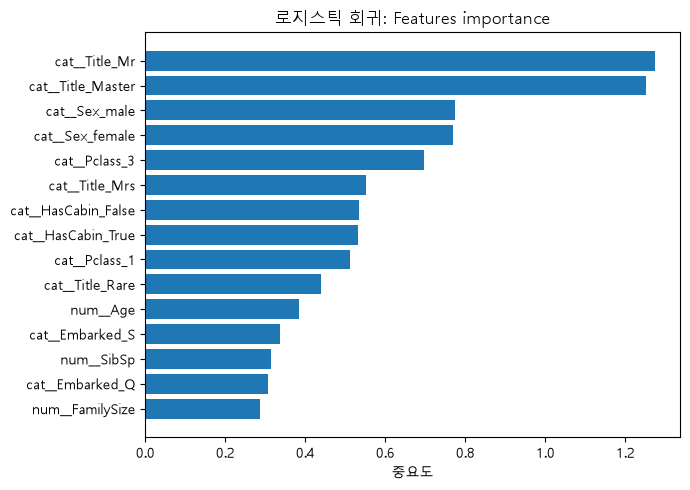

In [46]:
plot_confusion(log_reg_pipe, X_val, y_val, "로지스틱 회귀")
plot_feature_importance(log_reg_pipe, "로지스틱 회귀: Features importance")

In [23]:
## 8. 실험 2: 결정트리
#`max_depth`를 제한하지 않으면 train 정확도만 치솟는 과적합이 일어납니다. 실험 기록에서 train과 검증 정확도의 차이를 비교해 보세요.
tree_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
])

run_experiment("결정트리", tree_pipe, X_train, y_train, X_val, y_val)[
    ["실험명", "train 정확도", "검증 정확도", "CV 평균"]
]


,실험명,train 정확도,검증 정확도,CV 평균
0,로지스틱 회귀,0.832865,0.832402,0.824495
1,결정트리,0.869382,0.782123,0.797813


In [24]:
## 9. 실험 3: 랜덤 포레스트
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)),
])

run_experiment("랜덤 포레스트", rf_pipe, X_train, y_train, X_val, y_val)[
    ["실험명", "train 정확도", "검증 정확도", "CV 평균"]
]

,실험명,train 정확도,검증 정확도,CV 평균
0,로지스틱 회귀,0.832865,0.832402,0.824495
1,랜덤 포레스트,0.872191,0.821229,0.820290
2,결정트리,0.869382,0.782123,0.797813


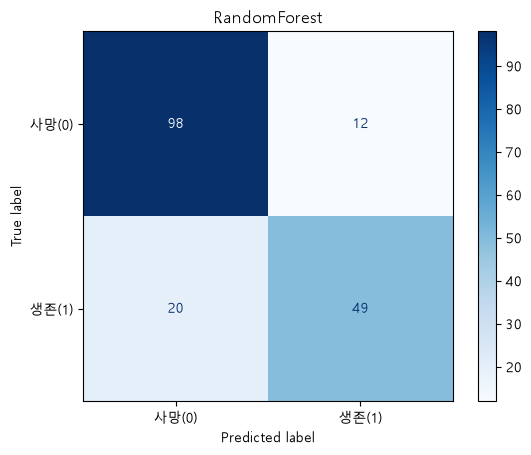

              precision    recall  f1-score   support

       사망(0)       0.83      0.89      0.86       110
       생존(1)       0.80      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



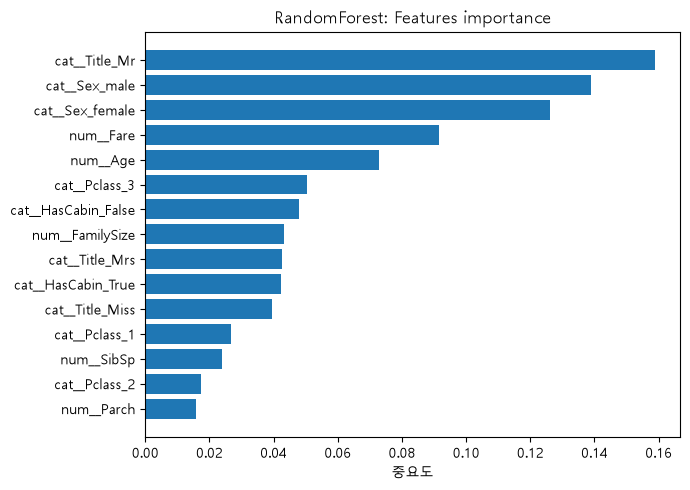

In [38]:
plot_confusion(rf_pipe, X_val, y_val, "RandomForest")
plot_feature_importance(rf_pipe, "RandomForest: Features importance")

In [39]:
## 10. 실험 4: 그레이디언트 부스팅
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=RANDOM_STATE)),
])

run_experiment("그레이디언트 부스팅", gb_pipe, X_train, y_train, X_val, y_val)[
    ["실험명", "train 정확도", "검증 정확도", "CV 평균"]
]

,실험명,train 정확도,검증 정확도,CV 평균
0,로지스틱 회귀,0.832865,0.832402,0.824495
1,랜덤 포레스트,0.872191,0.821229,0.820290
2,그레이디언트 부스팅,0.939607,0.810056,0.818940
3,그레이디언트 부스팅,0.939607,0.810056,0.818940
4,결정트리,0.869382,0.782123,0.797813


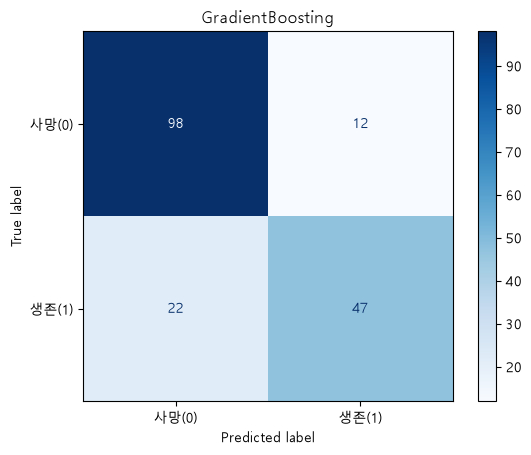

              precision    recall  f1-score   support

       사망(0)       0.82      0.89      0.85       110
       생존(1)       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



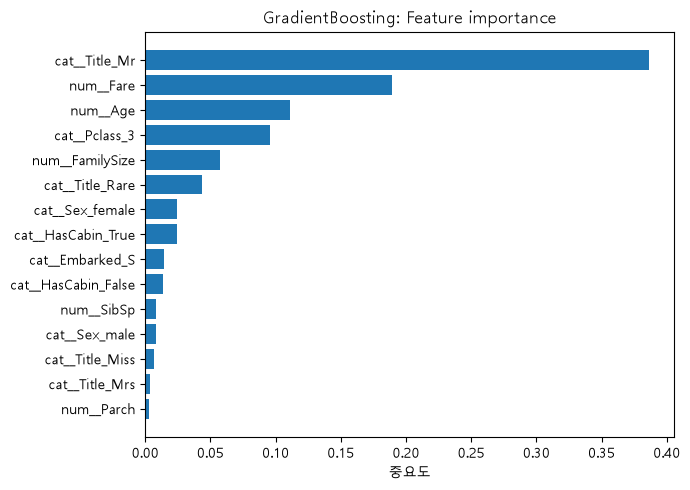

In [40]:
plot_confusion(gb_pipe, X_val, y_val, "GradientBoosting")
plot_feature_importance(gb_pipe, "GradientBoosting: Feature importance")

In [36]:
## 11. 실험 기록 한눈에 보기
# 지금까지의 실험을 정렬해서 비교합니다. train 정확도와 검증 정확도의 차이가 큰 모델은 과적합을 의심해 보세요.
# 하이퍼파라미터까지 포함한 전체 표가 궁금하면 `show_log()`를 그대로 호출하고, 관심 있는 컬럼만 보고 싶으면 컬럼 목록을 넘기면 됩니다.
# 예: `show_log(["실험명", "검증 정확도", "n_estimators", "max_depth"])`

log_df = show_log(["실험명", "train 정확도", "검증 정확도", "CV 평균", "CV 표준편차"])
log_df

,실험명,train 정확도,검증 정확도,CV 평균,CV 표준편차
0,로지스틱 회귀,0.832865,0.832402,0.824495,0.017723
1,랜덤 포레스트,0.872191,0.821229,0.820290,0.021448
2,그레이디언트 부스팅,0.939607,0.810056,0.818940,0.037157
3,결정트리,0.869382,0.782123,0.797813,0.030785


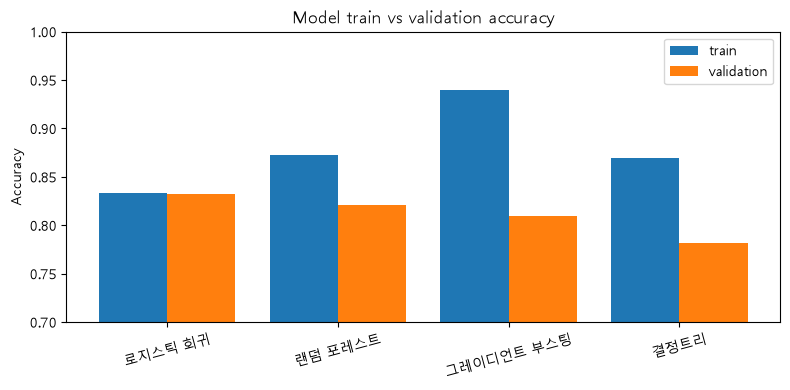

In [41]:
x = np.arange(len(log_df))
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, log_df["train 정확도"], width=0.4, label="train")
plt.bar(x + 0.2, log_df["검증 정확도"], width=0.4, label="validation")
plt.xticks(x, log_df["실험명"], rotation=15)
plt.ylim(0.7, 1.0)
plt.ylabel("Accuracy")
plt.title("Model train vs validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
# ## 12. 그리드 서치로 튜닝하기
# 가장 성능이 좋았던 모델을 골라서 하이퍼파라미터를 더 탐색해 봅시다. 여기서는 랜덤 포레스트로 진행합니다.
# `GridSearchCV`가 시도한 모든 조합은 `cv_results_`에 이미 표 형태로 정리되어 있습니다. 
# 우리가 직접 만든 `experiment_log`와 같은 아이디어를, 사이킷런은 내부적으로 이미 하고 있었던 거예요. 
# 이 결과를 우리 실험 기록에도 합쳐 봅니다.

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [4, 6, 8, None],
    "model__min_samples_leaf": [1, 3, 5],
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("최적 파라미터:", grid_search.best_params_)
print("최적 CV 점수:", grid_search.best_score_.round(4))

grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results[["params", "mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head()

최적 파라미터: {'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
최적 CV 점수: 0.8371


,params,mean_test_score,std_test_score
1,"{'model__max_depth': 4, 'model__min_samples_le...",0.837122,0.013058
2,"{'model__max_depth': 4, 'model__min_samples_le...",0.837122,0.013058
0,"{'model__max_depth': 4, 'model__min_samples_le...",0.834315,0.013905
4,"{'model__max_depth': 4, 'model__min_samples_le...",0.832916,0.016895
7,"{'model__max_depth': 4, 'model__min_samples_le...",0.831518,0.017746


In [44]:
# 그리드 서치 결과를 우리 실험 기록에도 합쳐 둡니다.
best_model = grid_search.best_estimator_

for _, row in grid_results.iterrows():
    entry = {
        "실험명": "랜덤 포레스트 (GridSearch)",
        "CV 평균": row["mean_test_score"],
        "CV 표준편차": row["std_test_score"],
    }
    entry.update(row["params"])
    experiment_log.append(entry)

# 최적 모델의 train/검증 정확도도 별도 실험으로 기록해 둡니다.
run_experiment("랜덤 포레스트 (최적)", best_model, X_train, y_train, X_val, y_val)[
    ["실험명", "train 정확도", "검증 정확도", "CV 평균"]
].head()

,실험명,train 정확도,검증 정확도,CV 평균
0,로지스틱 회귀,0.832865,0.832402,0.824495
1,랜덤 포레스트,0.872191,0.821229,0.820290
2,그레이디언트 부스팅,0.939607,0.810056,0.818940
3,그레이디언트 부스팅,0.939607,0.810056,0.818940
4,랜덤 포레스트 (최적),0.837079,0.793296,0.837122


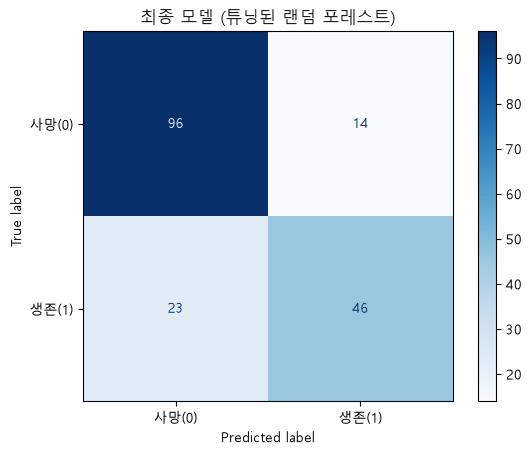

              precision    recall  f1-score   support

       사망(0)       0.81      0.87      0.84       110
       생존(1)       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



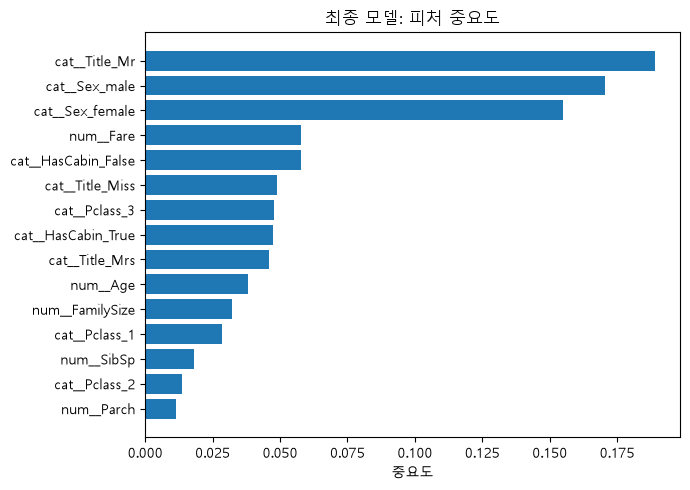

In [45]:
## 13. 최종 모델 평가
plot_confusion(best_model, X_val, y_val, "최종 모델 (튜닝된 랜덤 포레스트)")
plot_feature_importance(best_model, "최종 모델: 피처 중요도")